# 电商用户行为路径与购买转化归因分析

**数据来源**：公开电商用户行为日志  
**时间范围**：2017年11月25日 – 2017年12月4日（共10天）  
**数据量**：987,370 条行为记录，9,739 名用户  
**行为类型**：pv（点击）、fav（收藏）、cart（加购）、buy（购买）

---

## 🎯 分析目标

运营团队想知道：**什么样的前期行为真正驱动了最终购买？**

我从**三个维度**展开分析：
1. **用户行为路径**：对比“仅点击”、“点击+收藏”、“点击+加购”、“三者皆有”四组用户的购买转化率，找出最高转化路径。
2. **时间维度**：分析一天24小时内各行为的分布，定位高转化时段。
3. **商品品类维度**：对比点击、收藏、加购、购买 Top10 榜单的重合度，判断热度与成交是否一致。

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 设置中文字体（以黑体为例，Windows 可用 SimHei，macOS 可用 'Arial Unicode MS'）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 或 ['Microsoft YaHei']、['WenQuanYi Zen Hei']
plt.rcParams['axes.unicode_minus'] = False   # 解决负号显示异常

In [4]:
# 文件很大，读前10万行测试
df = pd.read_csv('D:/myproject/data/UserBehavior.csv', nrows=1000000, header=None)
# 添加列名
df.columns = ['user_id', 'item_id', 'category_id', 'behavior', 'timestamp']

In [5]:
#timestamp，时间列转换成时间类型，提取出日期和时间
df['timestamp'] = pd.to_datetime(df['timestamp'],unit='s')
df = df[df['timestamp'].between('2017-11-25', '2017-12-04')]
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

### 📊 整体数据概览

**核心指标：**
- 10天内共记录 **987,370** 条行为，覆盖 **9,739** 名用户、**395,692** 件商品、**5,777** 个品类。
- 人均浏览次数 **90.84** 次，成交量 **20,171** 笔。

**初步判断：**
用户浏览深度较高，但购买转化远低于浏览，存在明显的“逛得多买得少”现象。接下来的分析将聚焦于**哪些行为路径能提升转化**。

In [7]:
behavior_counts = df['behavior'].value_counts()

summary = pd.DataFrame({'用户数': df['user_id'].nunique(),
    '商品数': df['item_id'].nunique(),
    '商品数量类目': df['category_id'].nunique(),
    '行为总数': [len(df)],
    '点击数': behavior_counts['pv'],
    '人均浏览次数': behavior_counts['pv']/df['user_id'].nunique(),
    '成交量': behavior_counts['buy']})

# 新建格式化的表格，生成 Markdown
summary_md = pd.DataFrame({
    '指标': ['用户数', '商品数', '商品数量类目', '行为总数', '点击数', '人均浏览次数', '成交量'],
    '数值': [
        f"{summary.loc[0, '用户数']:,.0f}",
        f"{summary.loc[0, '商品数']:,.0f}",
        f"{summary.loc[0, '商品数量类目']:,.0f}",
        f"{summary.loc[0, '行为总数']:,.0f}",
        f"{summary.loc[0, '点击数']:,.0f}",
        f"{summary.loc[0, '人均浏览次数']:.2f}",
        f"{summary.loc[0, '成交量']:,.0f}"
    ]
})

# 改成markedown形式
print(summary_md.to_markdown(index=False))

| 用户数   | 商品数   | 商品数量类目   | 行为总数   | 点击数   |   人均浏览次数 | 成交量   |
|:---------|:---------|:---------------|:-----------|:---------|---------------:|:---------|
| 9,739    | 395,692  | 5,777          | 987,370    | 884,680  |          90.84 | 20,171   |


In [22]:
uv_series = df.groupby('date')['user_id'].nunique()           # Series，索引是日期
pv_series = df[df['behavior']=='pv'].groupby('date').size()   # Series，索引是日期
buy_series = df[df['behavior']=='buy'].groupby('date').size() # Series，索引是日期

summary_daily = pd.DataFrame({
    '日访客数': uv_series,
    '日点击数': pv_series,
    '日成交量': buy_series,
    '日人均点击量':pv_series/uv_series
}).fillna(0)   # 日期对齐后，缺失的补0
summary_daily = summary_daily.reset_index()  # 索引变成 'date' 列
summary_daily.rename(columns={'date': '日期'}, inplace=True)

# 在 Jupyter 中直接显示
summary_daily

,日期,日访客数,日点击数,日成交量,日人均点击量
0,2017-11-25,6977,94656,1938,13.566863
1,2017-11-26,7120,94037,2122,13.207444
2,2017-11-27,7003,87328,2191,12.470084
3,2017-11-28,7016,88913,2189,12.672891
4,2017-11-29,7141,91743,2300,12.847360
5,2017-11-30,7242,94533,2292,13.053438
6,2017-12-01,7402,100934,2193,13.636044
7,2017-12-02,9314,125130,2549,13.434615
8,2017-12-03,9092,107406,2397,11.813242


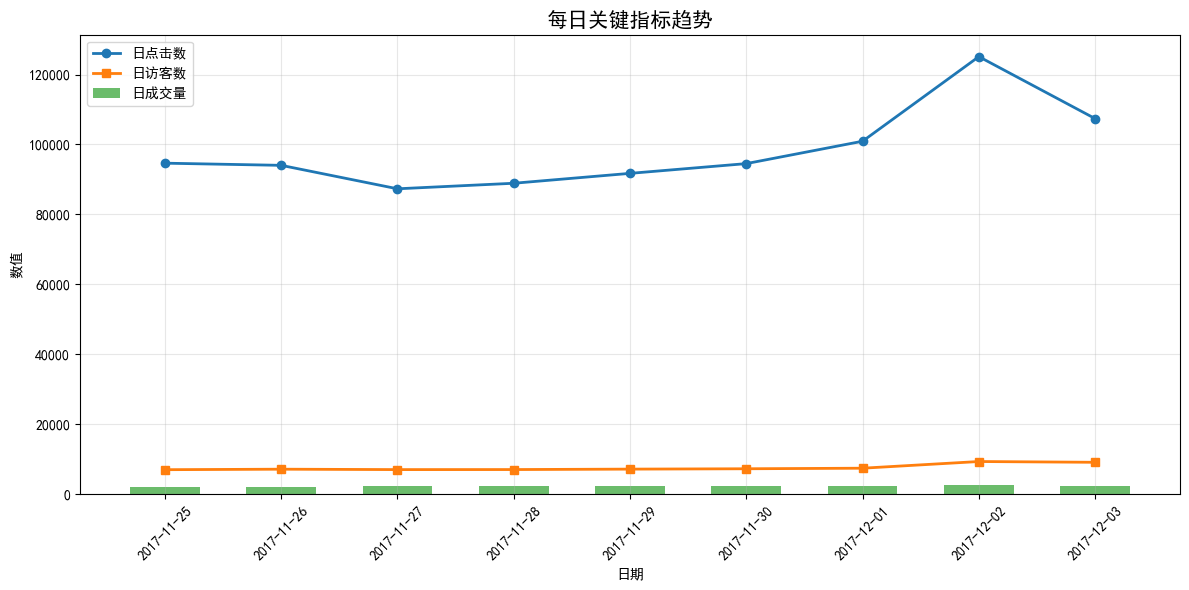

In [9]:
#创建画布和坐标轴
fig, ax = plt.subplots(figsize=(12, 6))

# ========== 绘制折线图（两条） ==========
# plot 函数：x 是日期，y 是数值，其余参数全部控制样式
ax.plot(summary_daily['日期'], summary_daily['日点击数'],
        color='#1f77b4',          # 线条颜色
        marker='o',               # 数据点标记形状
        linewidth=2,              # 线条宽度
        markersize=6,             # 标记大小
        linestyle='-',            # 线型：实线
        label='日点击数')         # 图例文字

ax.plot(summary_daily['日期'], summary_daily['日访客数'],
        color='#ff7f0e',
        marker='s',               # 方块标记
        linewidth=2,
        markersize=6,
        linestyle='-',           # 虚线
        label='日访客数')

# ========== 绘制柱状图（成交量） ==========
# bar 函数：x 是日期，height 是数值，width 控制柱宽
ax.bar(summary_daily['日期'], summary_daily['日成交量'],
       color='#2ca02c',          # 柱体颜色
       alpha=0.7,                # 柱体透明度
       width=0.6,                # 柱宽度（以天为单位，0.6 表示柱子宽度为 0.6 天）
       label='日成交量')

# ========== 图表装饰（标题、轴标签、图例、网格等） ==========
ax.set_title('每日关键指标趋势', fontsize=15, fontweight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('数值')
ax.legend(loc='upper left')        # 图例位置
ax.grid(True, alpha=0.3)           # 网格线，0.3 透明度
ax.tick_params(axis='x', rotation=45)  # x 轴刻度标签旋转 45 度
fig.tight_layout()
plt.show()

**📈 日均趋势结论：**
- 10天内的日访客数、点击数、成交量较为平稳，无剧烈波动，说明数据采集期间平台运营环境稳定，无异常促销事件干扰。
- 12月2日（周六）出现访问小高峰，成交量同步提升，符合周末流量上扬的普遍规律。
- 由于时间跨度较短，未能观察到周期间规律，后续分析将转向**小时粒度**和**用户行为路径**。

### 👥 用户粘性：复购率与跳失率

**定义：**
- 复购率 = 购买次数 ≥ 2 的用户 / 所有购买过的用户
- 跳失率 = 全生命周期内仅有点击行为的用户 / 所有有点击的用户（注：无 session 切割，口径偏严格）

**核心发现：**
- 复购率高达 **66.07%**，说明该平台有极强的用户复购粘性，用户一旦买过就很可能再次购买。
- 跳失率仅 **6.00%**，说明绝大多数点击用户会产生收藏或加购等进一步互动，平台内容或推荐能有效留住用户。

**这里有一个反常识点：复购率很高，但前面复购率计算的是“购买次数≥2”，而我后面分组分析时发现“仅点击”组没有复购行为——这之间的差异，正是我们接下来要深挖的重点。**

In [21]:
#复购率和跳失率
#复购率=购买次数>1的用户/所有购买用户
#跳失率=点击次数为1的用户/所有点击用户

# 为了复购率，我们只需要购买行为的数据
buy_df = df[df['behavior'] == 'buy']
# 购买次数 = 有多少不同的用户至少购买过一次
purchase_users = buy_df['user_id'].nunique()
# 统计每个用户的购买次数
user_buy_counts = buy_df.groupby('user_id').size()
# 复购用户 = 购买次数 >= 2 的用户
repeat_buyers = (user_buy_counts >= 2).sum()
repurchase_rate = repeat_buyers / purchase_users * 100

# 所有有点击行为的用户
pv_users = df[df['behavior'] == 'pv']['user_id'].unique()
total_pv_users = len(pv_users)

# 找出每个用户的所有行为类型（去重）
user_behavior_types = df.groupby('user_id')['behavior'].apply(set)

# 跳失用户：行为集合 == {'pv'}  （仅有点击，无其他）
churn_users = user_behavior_types[user_behavior_types == {'pv'}].index
churn_count = len(churn_users)

# 跳失率
churn_rate = churn_count / total_pv_users * 100 if total_pv_users > 0 else 0

summary_user = pd.DataFrame({
    '复购次数': repeat_buyers,
    '购买次数': purchase_users,
    '复购率': f"{repurchase_rate:.2f}%",
    '跳失率': f"{churn_rate:.2f}%"
},index=[0])

summary_user

,复购次数,购买次数,复购率,跳失率
0,4399,6658,66.07%,6.00%


In [11]:
# 构造方法，提取用户第一次购买前的所有行为
def get_behaviors_before_buy(group):
    """返回用户第一次购买之前的行为集合（不含购买本身）"""
    buy_mask = group['behavior'] == 'buy'
    if buy_mask.any():
        first_buy_idx = group[buy_mask].index[0]
        before = group.loc[group.index < first_buy_idx]
        return set(before['behavior'].unique())
    else:
        return set(group['behavior'].unique())  # 从未购买的用户

In [12]:
#将方法应用到每一行
user_behaviors = df.groupby('user_id').apply(get_behaviors_before_buy,include_groups=False).reset_index()
user_behaviors.columns = ['user_id', 'behaviors_set']

In [13]:
buy_users = set(df[df['behavior'] == 'buy']['user_id'])
user_behaviors['has_buy'] = user_behaviors['user_id'].isin(buy_users)

In [14]:
#对不同用户的购买前行为进行分组
def assign_group(behaviors):
    has_pv = 'pv' in behaviors
    has_fav = 'fav' in behaviors
    has_cart = 'cart' in behaviors
    if not has_pv:
        return '无点击'  # 理论上不会发生
    if has_fav and has_cart:
        return '点击+收藏+加购'
    elif has_cart and not has_fav:
        return '点击+加购'
    elif has_fav and not has_cart:
        return '点击+收藏'
    else:
        return '仅点击'

user_behaviors['group'] = user_behaviors['behaviors_set'].apply(assign_group)

In [15]:
#计算各分组的购买转化率
conversion = user_behaviors.groupby('group').agg(
    用户数=('user_id', 'count'),
    购买用户数=('has_buy', 'sum')
)

conversion['转化率(%)'] = (conversion['购买用户数'] / conversion['用户数'] * 100).round(2)
conversion = conversion.sort_values('转化率(%)', ascending=False).reset_index()
conversion = conversion[conversion['group'] != '无点击']

### 🔀 用户行为路径转化分析（核心发现）

**分析逻辑：**
提取用户首次购买前的所有行为，将用户分为四组，计算各组的最终购买转化率。

**关键数据：**
| 路径 | 用户数 | 购买用户数 | 转化率 |
|------|--------|------------|--------|
| 仅点击 | 2593 | 2011 | **77.55%** |
| 点击+加购 | 4027 | 2629 | 65.28% |
| 点击+收藏 | 1161 | 697 | 60.03% |
| 三者皆有 | 1534 | 903 | 58.87% |

**核心洞察：**
- 转化率最高的不是我们以为的“加购/收藏”组，反而是**“仅点击”组（77.55%）**。
- 我的初始假设被推翻，经反复检查代码确认无误。
- 这说明平台存在大量**即搜即买的刚性需求用户**，他们无需收藏或加购，直接下单完成购买。
- 收藏和加购行为更多是**决策延迟和比价的信号**，对应用户转化周期长、流失风险高。

**业务启发：产品端不应强迫用户加购，而要保证直接购买路径的极致顺畅。**

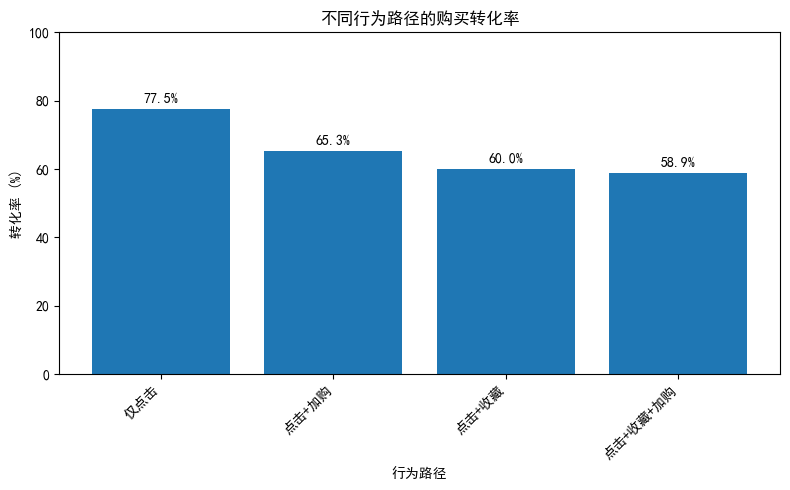

In [16]:
#可视化
plt.figure(figsize=(8,5))
bars = plt.bar(conversion.index, conversion['转化率(%)'])
plt.xlabel('行为路径')
plt.ylabel('转化率 (%)')
plt.title('不同行为路径的购买转化率')
plt.ylim(0, 100)  # 设置 y 轴最大为 100
plt.xticks(ticks=conversion.index, labels=conversion['group'], rotation=45, ha='right')

# 添加数据标签（自动放置在柱子顶部）
plt.bar_label(bars, fmt='%.1f%%', padding=3)

plt.tight_layout()
plt.show()

In [17]:
#添加小时列
df['hour'] = df['timestamp'].dt.hour
#统计每个小时、每种行为的数量
hourly_long = df.groupby(['hour', 'behavior']).size().reset_index(name='count')
long_hourly = df.groupby(['behavior', 'hour']).size().reset_index(name='count')

# 将长格式转为宽格式
hourly_wide = hourly_long.pivot(index='hour', columns='behavior', values='count').fillna(0)

# 按顺序排序列（点击、收藏、加购、购买）
hourly_wide = hourly_wide[['pv', 'fav', 'cart', 'buy']]

# 确保所有小时 0-23 都存在（如果没有数据则补0）
hourly_wide = hourly_wide.reindex(range(24), fill_value=0)

# 重置索引，使 hour 成为普通列（可选）
hourly_wide = hourly_wide.reset_index().rename_axis(None, axis=1)

### ⏰ 24小时行为分布与转化效率

**分析目的：** 找出一天中哪种行为在哪个时段集中，识别高转化窗口。

**关键发现：**
- 平台流量高峰在 **12-14点**（中午）和 **19-21点**（晚间）。
- 但凌晨 **0-2点** 的购买行为相对点击量的比例（buy/pv）明显高于白天峰值时段，说明存在一群“夜间静默决策型用户”，在安静时段下单意愿更强。
- 收藏和加购行为与PV走势基本一致，无独立峰值。

**运营建议：** 在凌晨 0-2 点设置限量闪购或定向优惠，用低成本撬动高转化。

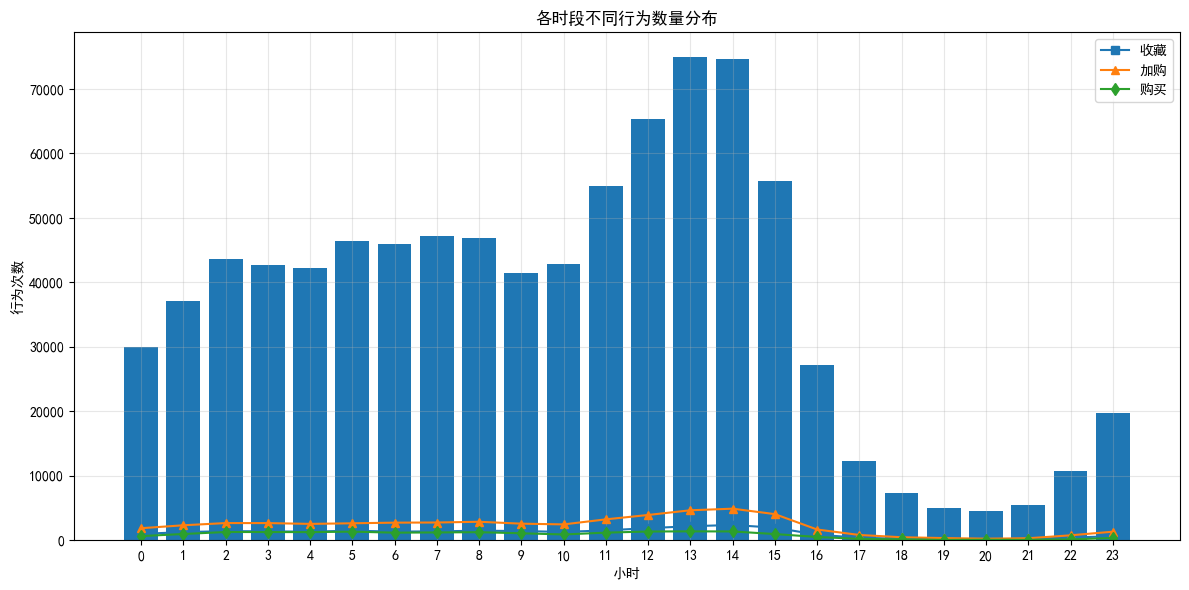

In [18]:
plt.figure(figsize=(12, 6))
plt.bar(hourly_wide.index, hourly_wide['pv'])
plt.plot(hourly_wide.index, hourly_wide['fav'] , marker='s', label='收藏')
plt.plot(hourly_wide.index, hourly_wide['cart'] , marker='^', label='加购')
plt.plot(hourly_wide.index, hourly_wide['buy'] , marker='d', label='购买')
plt.xlabel('小时')
plt.ylabel('行为次数')
plt.title('各时段不同行为数量分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0,24))  # 显示0-23
plt.tight_layout()
plt.show()

In [19]:
#
category_behavior = df.groupby(['category_id', 'behavior']).size().unstack(fill_value=0)
# 确保列存在
for col in ['pv', 'fav', 'cart', 'buy']:
    if col not in category_behavior.columns:
        category_behavior[col] = 0
# 重命名列名为中文
category_behavior.rename(columns={'pv': '点击', 'fav': '收藏', 'cart': '加购', 'buy': '购买'}, inplace=True)
# 现在列名已经是中文
category_behavior = category_behavior[['点击', '收藏', '加购', '购买']]
top_pv = category_behavior.nlargest(10, '点击').index.tolist()
top_fav = category_behavior.nlargest(10, '收藏').index.tolist()
top_cart = category_behavior.nlargest(10, '加购').index.tolist()
top_buy = category_behavior.nlargest(10, '购买').index.tolist()

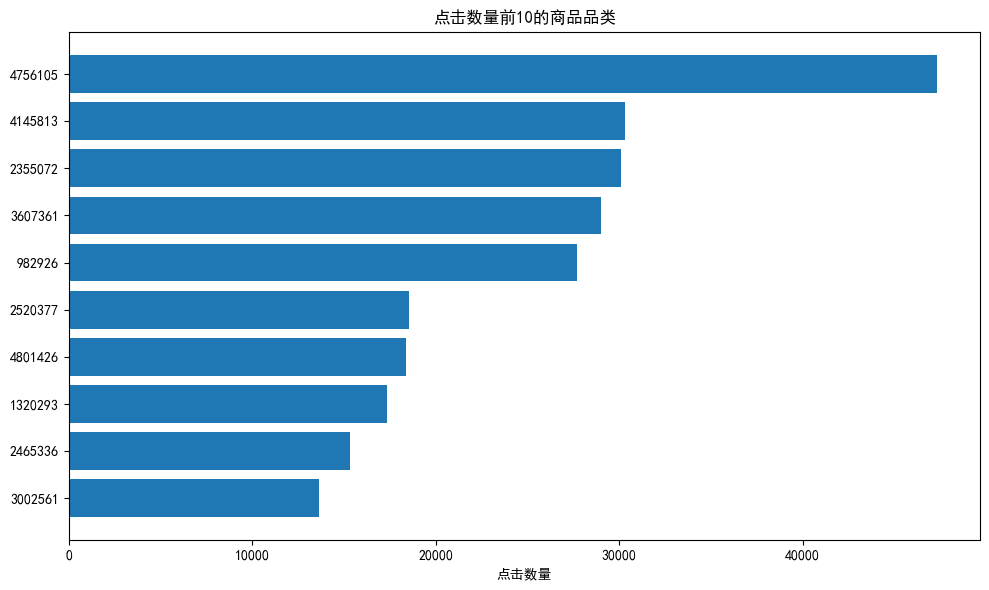

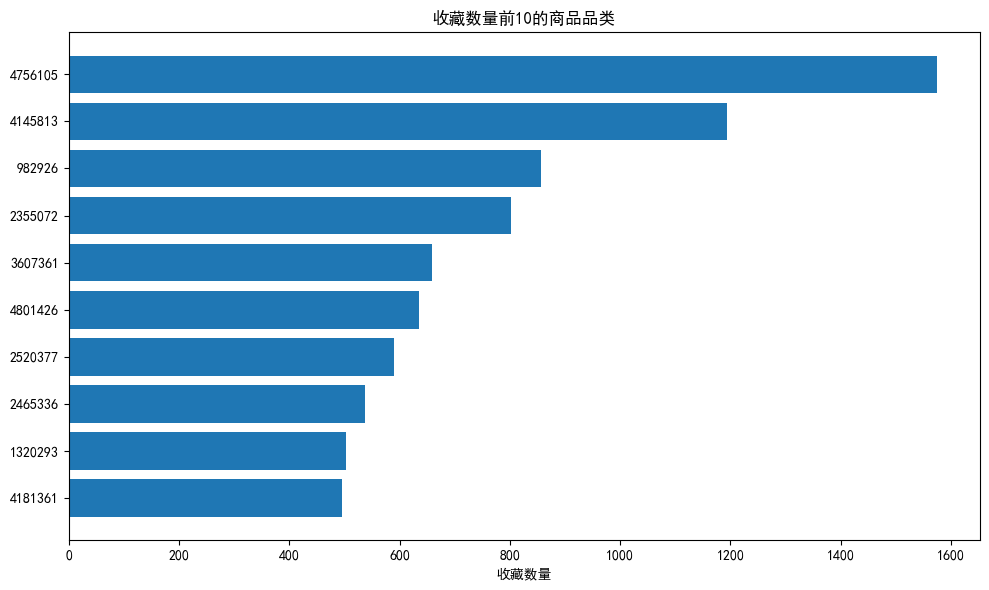

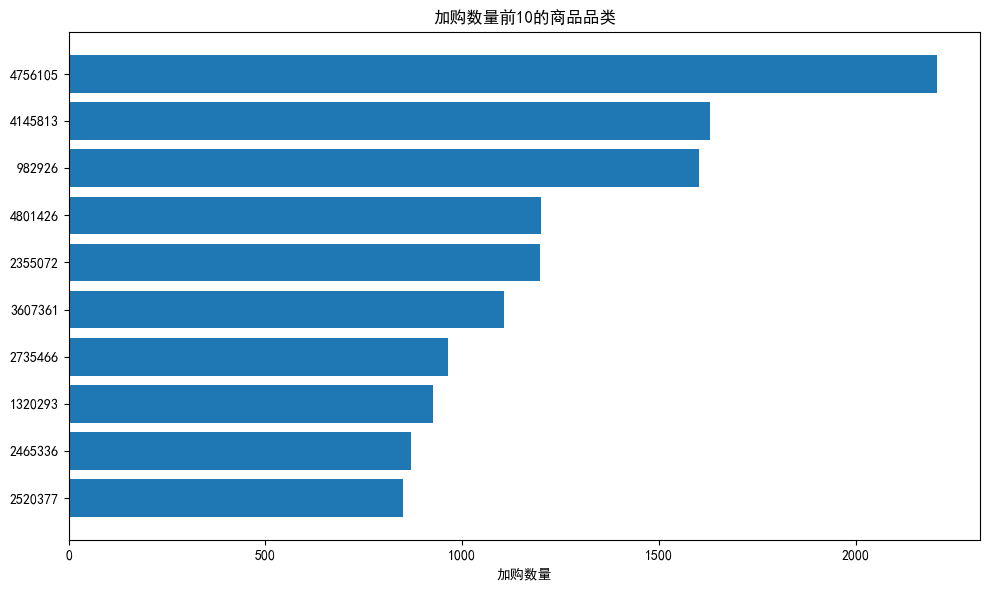

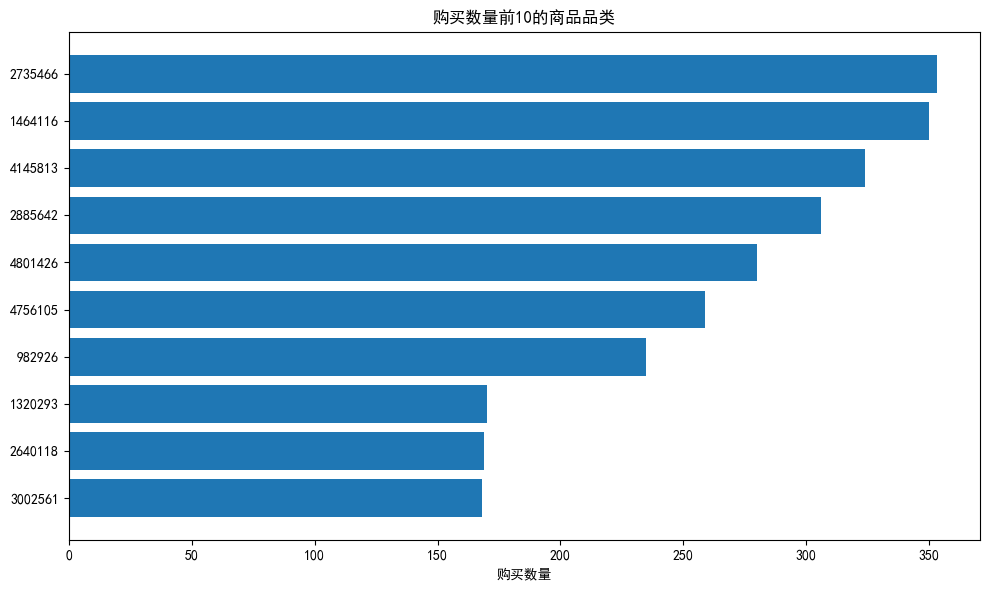

In [20]:
# 直接取 top10 的索引作为品类ID
for behavior in category_behavior:
    top10_series = category_behavior.nlargest(10, behavior)[behavior]  # Series，索引是category_id
    top10_ids = top10_series.index.astype(str)
    top10_vals = top10_series.values
    
    plt.figure(figsize=(10,6))
    plt.barh(top10_ids, top10_vals)
    plt.xlabel(behavior.upper() + '数量')
    plt.title(f'{behavior.upper()}数量前10的商品品类')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

### 🛍️ 商品品类热度 vs 成交

**分析逻辑：** 分别取 PV、收藏、加购、购买 Top10 品类，计算两两重合数。

**结论：**
- 购买 Top10 与加购 Top10 重合 **6** 个，与收藏 Top10 重合 **5** 个。
- 加购 Top10 与收藏 Top10 重合 **9** 个，说明“兴趣清单”高度一致，但与实际购买存在 **约40% 的错位**。
- 这意味着有一批品类是用户“看了又看、收藏加购却不买单”的，属于**高热度低转化品类**。

**策略建议：**
- 对高热度低转化品类，推送“收藏后 24 小时内下单折扣”，缩短犹豫期。
- 对购买榜上独有的品类（高转化低热度），增加搜索推荐曝光，承接直接购买需求。

## 💡 业务建议总结

1. **产品层面**：优化“立即购买”按钮，缩短从商品页到支付完成的步骤，不打断刚需用户的直接下单路径。
2. **运营层面**：设立“夜猫子专区”，在凌晨 0-2 点开放限时折扣，激活夜间高转化用户。
3. **商品层面**：区分“引流款”与“利润款”，对收藏高购买低的品类定向发券催转化，对购买高收藏低的品类强化曝光。

## ⚠️ 局限性与后续改进

- **数据周期短**：仅10天数据，无法排除周末/活动效应，结论需更长周期验证。
- **无金额字段**：无法计算用户价值分层，复购的“质”无法衡量。
- **无 Session 定义**：跳失率基于全局行为集合，后续可引入30分钟session切割使口径更标准。
- **未做统计检验**：可对分组转化率差异做卡方检验，增强结论置信度。

如果未来能获取价格、用户画像、渠道来源等字段，可构建逻辑回归预测模型，并通过A/B测试验证策略效果。